# Camera-only BEV Fusion pipeline

In [12]:
# ============================================================
# Allow notebook to import MMDetection3D + BEVFusion project
# ============================================================

import sys
from pathlib import Path

MMDET3D_ROOT = "/home/edgelab/mmdetection3d"

if MMDET3D_ROOT not in sys.path:
    sys.path.insert(0, MMDET3D_ROOT)

# verify path works
assert Path(MMDET3D_ROOT, "projects", "BEVFusion").exists()

print("MMDetection3D root added:", MMDET3D_ROOT)

MMDetection3D root added: /home/edgelab/mmdetection3d


In [13]:
from mmengine.registry import init_default_scope
init_default_scope("mmdet3d")

# This line registers GeneralizedLSSFPN and DepthLSSTransform
import projects.BEVFusion.bevfusion

device: cuda
npz_path: /home/edgelab/multimodal-MoE/outputs/tmp/060350_front_camera_bev_artifacts_1248x704.npz
img_path: /home/edgelab/multimodal-MoE/outputs/tmp/060350_front_undistorted_resized_1248x704.png

Loaded array shapes:
K_bev: (3, 3)
cam2ego: (4, 4)
lidar2ego: (4, 4)
lidar2cam: (4, 4)
cam2lidar: (4, 4)
lidar2img: (3, 4)

Loaded image shape: (704, 1248, 3)


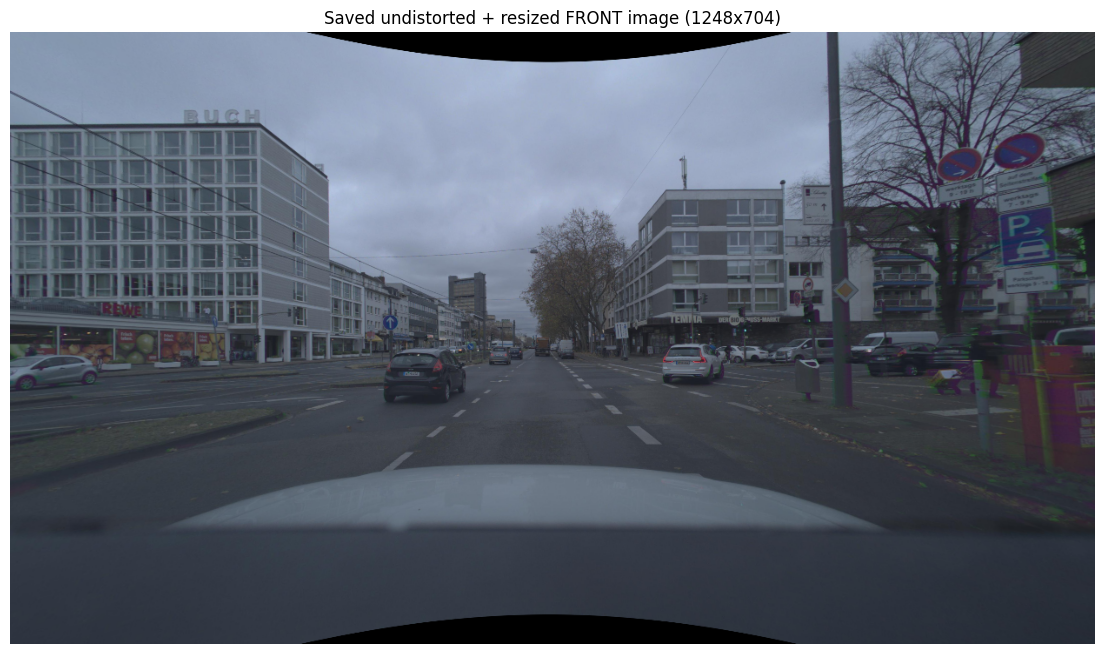


img_tensor shape [B,N,C,H,W]: (1, 1, 3, 704, 1248)

Runtime tensor shapes:
camera2ego: (1, 1, 4, 4)
lidar2ego_t: (1, 1, 4, 4)
lidar2camera: (1, 1, 4, 4)
camera2lidar: (1, 1, 4, 4)
lidar2image: (1, 1, 3, 4)
camera_intrinsics: (1, 1, 3, 3)
img_aug_matrix: (1, 1, 4, 4)
lidar_aug_matrix: (1, 4, 4)
points[0]: (73883, 3)


In [38]:
# ============================================================
# Load saved BEVFusion camera artifacts for one FRONT keyframe
#
# Expects the simplified artifact file that stores:
#   K_bev         : [3,3]
#   cam2ego       : [4,4]
#   lidar2ego     : [4,4]
#   lidar2cam     : [4,4]
#   cam2lidar     : [4,4]
#   lidar2img_bev : [3,4]
#
# Runtime tensors are built in the shapes expected by the
# default BEVFusion camera branch.
# ============================================================

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

ROOT = Path("/home/edgelab/multimodal-MoE/outputs/tmp")
FRAME_ID = "060350"

npz_path = ROOT / f"{FRAME_ID}_front_camera_bev_artifacts_1248x704.npz"
img_path = ROOT / f"{FRAME_ID}_front_undistorted_resized_1248x704.png"

print("npz_path:", npz_path)
print("img_path:", img_path)

data = np.load(npz_path)

# ------------------------------------------------------------
# Load saved arrays
# ------------------------------------------------------------
K_bev = data["K_bev"].astype(np.float32)                 # [3,3]
cam2ego = data["cam2ego"].astype(np.float32)             # [4,4]
lidar2ego = data["lidar2ego"].astype(np.float32)         # [4,4]
lidar2cam = data["lidar2cam"].astype(np.float32)         # [4,4]
cam2lidar = data["cam2lidar"].astype(np.float32)         # [4,4]
lidar2img = data["lidar2img_bev"].astype(np.float32)     # [3,4]

print("\nLoaded array shapes:")
print("K_bev:", K_bev.shape)
print("cam2ego:", cam2ego.shape)
print("lidar2ego:", lidar2ego.shape)
print("lidar2cam:", lidar2cam.shape)
print("cam2lidar:", cam2lidar.shape)
print("lidar2img:", lidar2img.shape)

# ------------------------------------------------------------
# Load saved image as BGR to match BEVFusion preprocessing
# ------------------------------------------------------------
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
assert img_bgr is not None, f"Could not read image: {img_path}"

H, W = img_bgr.shape[:2]
print("\nLoaded image shape:", img_bgr.shape)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Saved undistorted + resized FRONT image ({W}x{H})")
plt.axis("off")
plt.show()

# ------------------------------------------------------------
# Normalize image like OpenMMLab camera branch
# ------------------------------------------------------------
mean = np.array([123.675, 116.28, 103.53], dtype=np.float32).reshape(1, 1, 3)
std = np.array([58.395, 57.12, 57.375], dtype=np.float32).reshape(1, 1, 3)

img_norm = (img_bgr.astype(np.float32) - mean) / std

# [H,W,C] -> [C,H,W] -> [B,N,C,H,W]
img_tensor = torch.from_numpy(img_norm).permute(2, 0, 1).contiguous()
img_tensor = img_tensor.unsqueeze(0).unsqueeze(0).to(device)

print("\nimg_tensor shape [B,N,C,H,W]:", tuple(img_tensor.shape))

# ------------------------------------------------------------
# Build runtime geometry tensors
# ------------------------------------------------------------

# Per-camera tensors: [B,N,...]
camera2ego = torch.from_numpy(cam2ego).unsqueeze(0).unsqueeze(0).to(device)         # [1,1,4,4]
lidar2ego_t = torch.from_numpy(lidar2ego).unsqueeze(0).unsqueeze(0).to(device)      # [1,1,4,4]
lidar2camera = torch.from_numpy(lidar2cam).unsqueeze(0).unsqueeze(0).to(device)     # [1,1,4,4]
camera2lidar = torch.from_numpy(cam2lidar).unsqueeze(0).unsqueeze(0).to(device)     # [1,1,4,4]
lidar2image = torch.from_numpy(lidar2img).unsqueeze(0).unsqueeze(0).to(device)      # [1,1,3,4]
camera_intrinsics = torch.from_numpy(K_bev).unsqueeze(0).unsqueeze(0).to(device)    # [1,1,3,3]

# Image augmentation is per camera: [B,N,4,4]
img_aug_matrix = torch.eye(4, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# LiDAR augmentation is per sample: [B,4,4]
lidar_aug_matrix = torch.eye(4, dtype=torch.float32).unsqueeze(0).to(device)

# ------------------------------------------------------------
# LiDAR points for DepthLSSTransform
# It uses only XYZ for sparse depth projection.
#
# Assumes fov_points_ego_xyzi is already defined in notebook.
# ------------------------------------------------------------
assert "fov_points_ego_xyzi" in globals(), \
    "fov_points_ego_xyzi must already be defined in this notebook."

points_xyz = fov_points_ego_xyzi[:, :3].astype(np.float32)
points = [torch.from_numpy(points_xyz).to(device)]   # list of length B

# Metadata list of length B
metas = [dict(frame_id=str(FRAME_ID), camera_name="FC")]

print("\nRuntime tensor shapes:")
print("camera2ego:", tuple(camera2ego.shape))
print("lidar2ego_t:", tuple(lidar2ego_t.shape))
print("lidar2camera:", tuple(lidar2camera.shape))
print("camera2lidar:", tuple(camera2lidar.shape))
print("lidar2image:", tuple(lidar2image.shape))
print("camera_intrinsics:", tuple(camera_intrinsics.shape))
print("img_aug_matrix:", tuple(img_aug_matrix.shape))
print("lidar_aug_matrix:", tuple(lidar_aug_matrix.shape))
print("points[0]:", tuple(points[0].shape))

In [39]:
# ------------------------------------------------------------
# GET Lidar Points: Read raw binary float32 values
# ------------------------------------------------------------
bin_path = ROOT / f"{FRAME_ID}_fov_points_ego_xyzi.bin"
raw = np.fromfile(bin_path, dtype=np.float32)
print(f"raw.shape: {raw.shape}")

# ------------------------------------------------------------
# Reshape into (N,4) → [x,y,z,intensity]
# ------------------------------------------------------------

fov_points_ego_xyzi = raw.reshape(-1, 4)
print(f"fov_points_ego_xyzi.shape: {fov_points_ego_xyzi.shape}")

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("Loaded file:", bin_path)
print("Dtype:", fov_points_ego_xyzi.dtype)
print("First point:", fov_points_ego_xyzi[0] if len(fov_points_ego_xyzi) else "EMPTY")


raw.shape: (295532,)
fov_points_ego_xyzi.shape: (73883, 4)
Loaded file: /home/edgelab/multimodal-MoE/outputs/tmp/060350_fov_points_ego_xyzi.bin
Dtype: float32
First point: [47.478405 56.58517   8.407365 62.      ]


In [40]:
# ============================================================
# Build the camera-only BEVFusion modules
# ============================================================

from mmdet.models.backbones import SwinTransformer

print("mmdet3d GeneralizedLSSFPN registered:",
      "GeneralizedLSSFPN" in MMDET3D_MODELS.module_dict)
print("mmdet3d DepthLSSTransform registered:",
      "DepthLSSTransform" in MMDET3D_MODELS.module_dict)

# ------------------------------------------------------------
# 1) Swin backbone
# IMPORTANT: do NOT chain .eval() here
# Some OpenMMLab backbones override train() without returning self,
# so .eval() can return None.
# ------------------------------------------------------------
img_backbone = SwinTransformer(
    pretrain_img_size=224,
    in_channels=3,
    embed_dims=96,
    depths=[2, 2, 6, 2],
    num_heads=[3, 6, 12, 24],
    window_size=7,
    mlp_ratio=4,
    qkv_bias=True,
    qk_scale=None,
    drop_rate=0.0,
    attn_drop_rate=0.0,
    drop_path_rate=0.2,
    patch_norm=True,
    out_indices=(1, 2, 3),
    with_cp=False,
    convert_weights=True,
)
img_backbone.to(device)
img_backbone.eval()

# ------------------------------------------------------------
# 2) GeneralizedLSSFPN
# Safer to avoid chaining here too for consistency
# ------------------------------------------------------------
img_neck = MMDET3D_MODELS.build(
    dict(
        type="GeneralizedLSSFPN",
        in_channels=[192, 384, 768],
        out_channels=256,
        start_level=0,
        num_outs=3,
        norm_cfg=dict(type="BN2d", requires_grad=True),
        act_cfg=dict(type="ReLU", inplace=True),
        upsample_cfg=dict(mode="bilinear", align_corners=False),
    )
)
img_neck.to(device)
img_neck.eval()

# ------------------------------------------------------------
# 3) DepthLSSTransform
# ------------------------------------------------------------
view_transform = MMDET3D_MODELS.build(
    dict(
        type="DepthLSSTransform",
        in_channels=256,
        out_channels=80,
        image_size=[704, 1248],
        feature_size=[88, 156],
        xbound=[-54.0, 54.0, 0.3],
        ybound=[-54.0, 54.0, 0.3],
        zbound=[-10.0, 10.0, 20.0],
        dbound=[1.0, 60.0, 0.5],
        downsample=2,
    )
)
view_transform.to(device)
view_transform.eval()

print("\nBuilt modules:")
print("img_backbone:", type(img_backbone))
print("img_neck:", type(img_neck))
print("view_transform:", type(view_transform))

assert img_backbone is not None, "img_backbone is None"
assert img_neck is not None, "img_neck is None"
assert view_transform is not None, "view_transform is None"

mmdet3d GeneralizedLSSFPN registered: True
mmdet3d DepthLSSTransform registered: True

Built modules:
img_backbone: <class 'mmdet.models.backbones.swin.SwinTransformer'>
img_neck: <class 'projects.BEVFusion.bevfusion.bevfusion_necks.GeneralizedLSSFPN'>
view_transform: <class 'projects.BEVFusion.bevfusion.depth_lss.DepthLSSTransform'>


points_for_depth_lss[0] shape: (73883, 4)
lidar_aug_matrix shape: (1, 4, 4)

imgs_flat shape: (1, 3, 704, 1248)

Number of backbone feature maps: 3
backbone_feats[0] shape: (1, 192, 88, 156)
backbone_feats[1] shape: (1, 384, 44, 78)
backbone_feats[2] shape: (1, 768, 22, 39)

Number of neck feature maps: 2
neck_feats[0] shape: (1, 256, 88, 156)
neck_feats[1] shape: (1, 256, 44, 78)

img_feats_for_lss shape [B,N,C,Hf,Wf]: (1, 1, 256, 88, 156)

BEV feature tensor shape: (1, 80, 180, 180)


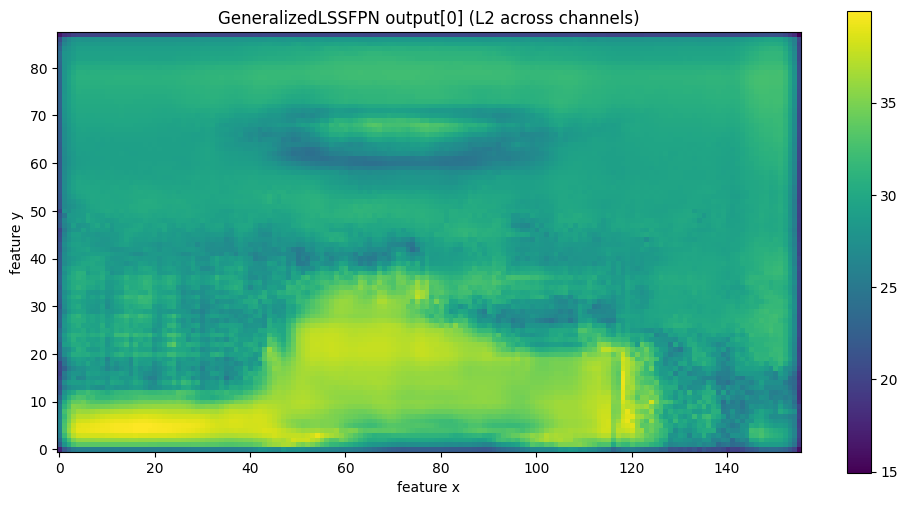

Collapsed BEV summary shape: (180, 180)


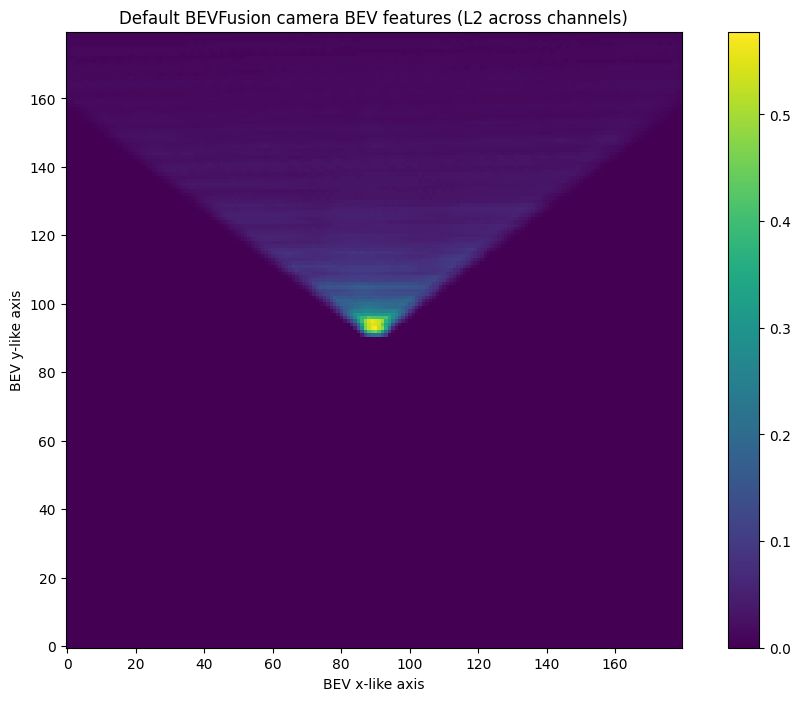

In [41]:
# ============================================================
# Forward pass through default BEVFusion camera branch
# ============================================================

assert "fov_points_ego_xyzi" in globals(), \
    "fov_points_ego_xyzi must already be defined."

# Use raw point tensor for now
points_for_depth_lss = [torch.from_numpy(fov_points_ego_xyzi.astype(np.float32)).to(device)]

print("points_for_depth_lss[0] shape:", tuple(points_for_depth_lss[0].shape))
print("lidar_aug_matrix shape:", tuple(lidar_aug_matrix.shape))

with torch.no_grad():
    B, N, C, H, W = img_tensor.shape

    imgs_flat = img_tensor.view(B * N, C, H, W)
    print("\nimgs_flat shape:", tuple(imgs_flat.shape))

    backbone_feats = img_backbone(imgs_flat)

    print("\nNumber of backbone feature maps:", len(backbone_feats))
    for i, feat in enumerate(backbone_feats):
        print(f"backbone_feats[{i}] shape:", tuple(feat.shape))

    neck_feats = img_neck(backbone_feats)

    print("\nNumber of neck feature maps:", len(neck_feats))
    for i, feat in enumerate(neck_feats):
        print(f"neck_feats[{i}] shape:", tuple(feat.shape))

    img_feats_for_lss = neck_feats[0]
    _, Cn, Hf, Wf = img_feats_for_lss.shape
    img_feats_for_lss = img_feats_for_lss.view(B, N, Cn, Hf, Wf)

    print("\nimg_feats_for_lss shape [B,N,C,Hf,Wf]:", tuple(img_feats_for_lss.shape))

    bev_feats = view_transform(
        img_feats_for_lss,
        points_for_depth_lss,
        lidar2image,
        camera_intrinsics,
        camera2lidar,
        img_aug_matrix,
        lidar_aug_matrix,
        metas,
    )

    print("\nBEV feature tensor shape:", tuple(bev_feats.shape))

# ------------------------------------------------------------
# Visualize FPN feature summary
# ------------------------------------------------------------
neck0 = neck_feats[0].detach().cpu()[0]
neck0_l2 = torch.norm(neck0, dim=0).numpy()

plt.figure(figsize=(12, 6))
plt.imshow(neck0_l2, origin="lower", aspect="equal")
plt.title("GeneralizedLSSFPN output[0] (L2 across channels)")
plt.xlabel("feature x")
plt.ylabel("feature y")
plt.colorbar()
plt.show()

# ------------------------------------------------------------
# Visualize BEV feature summary
# ------------------------------------------------------------
bev0 = bev_feats.detach().cpu()[0]
bev_l2 = torch.norm(bev0, dim=0).numpy()

print("Collapsed BEV summary shape:", bev_l2.shape)

plt.figure(figsize=(12, 8))
plt.imshow(bev_l2.T, origin="lower", aspect="equal")
plt.title("Default BEVFusion camera BEV features (L2 across channels)")
plt.xlabel("BEV x-like axis")
plt.ylabel("BEV y-like axis")
plt.colorbar()
plt.show()

In [34]:
print("img_tensor:", tuple(img_tensor.shape))
print("camera_intrinsics:", tuple(camera_intrinsics.shape))
print("camera2lidar:", tuple(camera2lidar.shape))
print("lidar2image:", tuple(lidar2image.shape))
print("img_aug_matrix:", tuple(img_aug_matrix.shape))
print("lidar_aug_matrix:", tuple(lidar_aug_matrix.shape))
print("points_for_depth_lss[0]:", tuple(points_for_depth_lss[0].shape))

img_tensor: (1, 1, 3, 704, 1248)
camera_intrinsics: (1, 1, 4, 4)
camera2lidar: (1, 1, 4, 4)
lidar2image: (1, 1, 4, 4)
img_aug_matrix: (1, 1, 4, 4)
lidar_aug_matrix: (1, 1, 4, 4)
points_for_depth_lss[0]: (73883, 3)
